# Analisi e classificazione delle e-mail per la rilevazione di messaggi SPAM

ProfessionAI, azienda specializzata nell'automazione basata sull'Intelligenza Artificiale, vuole sviluppare una libreria software in grado di analizzare e classificare le email ricevute. L'obiettivo principale è identificare le email di tipo SPAM per condurre successivamente delle analisi approfondite sui contenuti. Il CEO ha espresso l'esigenza di focalizzarsi su email SPAM per comprendere meglio le tendenze, i contenuti e i comportamenti associati. Queste informazioni verranno utilizzate per migliorare la sicurezza delle comunicazioni aziendali e perfezionare i filtri anti-spam.

<br>

### Obiettivi del Progetto
Il CTO ha fornito un dataset di email per realizzare le seguenti attività:

- addestrare un classificatore per identificare le email SPAM;
- individuare i Topic principali tra le email classificate come SPAM;
- calcolare la distanza semantica tra i topics ottenuti per valutare l'eterogeneità dei contenuti delle email SPAM;
- estrarre dalle email NON SPAM le informazioni sulle Organizzazioni menzionate.

<br>

### Valore Aggiunto
L'analisi delle email permetterebbe a ProfessionAI di ottenere diversi vantaggi strategici:

- miglioramento del filtro anti-spam: un classificatore efficiente permette di ridurre significativamente il volume di email indesiderate che raggiungono la casella di posta, ottimizzando la gestione delle comunicazioni aziendali;
- analisi contenutistica approfondita: L'individuazione dei principali topic trattati nelle email SPAM consente di ottenere informazioni preziose sui trend, tematiche e schemi ricorrenti, potenziando le strategie di cybersecurity;
- valutazione dell'eterogeneità: La distanza semantica tra i topic consente di comprendere la diversità dei contenuti SPAM, utile per ottimizzare le difese contro un'ampia gamma di attacchi;
- identificazione di organizzazioni: l'estrazione di organizzazioni dalle email legittime può essere sfruttata per migliorare i processi di business intelligence e gestire meglio le comunicazioni con clienti e partner.

<br>

### Conclusione
Il progetto offrirà a ProfessionAI un'analisi completa delle email ricevute, con particolare focus sull'identificazione delle email SPAM e l'analisi dei loro contenuti. Grazie alla segmentazione dei topic e all'analisi semantica, l'azienda potrà migliorare significativamente i propri filtri anti-spam e ottenere insight sui contenuti di maggiore rilevanza, nonché ottimizzare la gestione delle comunicazioni aziendali tramite l'estrazione di informazioni chiave dalle email legittime.

Questa soluzione incrementerà la sicurezza delle comunicazioni e migliorerà i processi decisionali aziendali, generando un vantaggio competitivo nel settore.

## 0) Approccio di lavoro e import delle librerie
Per la costruzione del fitlro anti-spam ci baseremo su una strategia già adottata durante la progettualità 7 utilizzando una rete neurale ricorrente (LSTM) che aveva mostrato risultati interessanti. Per questo task, una LSTM è in grado di analizzare il contenuto testuale dei messaggi per rilevare pattern ricorrenti, nel nostro caso tipici dello spam. Il modello apprenderà la sequenza delle parole per classificare i messaggi in "spam" o "non spam" con una certa rilevanza. Prima di definire l'architettura neurale, avremo bisogno di procedere con una fase iniziale di data preparation. Di seguito iniziamo a importare tutte le librerie necessarie alla costruzione del filtro.

In [ ]:
#Connessione al drive e cleaning delle sessioni precedenti
#import os
#if os.path.exists('/content/drive'):
    #!rm -rf /content/drive

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re, random
from collections import Counter
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, GRU, Flatten
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.utils import resample
from keras.layers import BatchNormalization
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string
import keras_tuner as kt

## 1) Data Exploration
In questa fase iniziale, analizziamo il file CSV di input contenente la lista dei commenti associati alla rispettiva classificazione spam o no spam. L’obiettivo è comprendere la struttura dei dati al fine di applicare le opportune tecniche di data cleaning e data preparation, propedeutiche all’addestramento del modello.

In [ ]:
#CSV loading
url = '/content/drive/MyDrive/ProfessionAI-Progetto8-MatteoMarcoCosta/spam_dataset.csv'
df = pd.read_csv(url)

In [ ]:
#Print delle prime righe del csv
df.head()

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\nth...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\n( see a...",0
2,3624,ham,"Subject: neon retreat\nho ho ho , we ' re arou...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\nthis deal is to ...,0


Notiamo che la struttura del dataset è abbastanza semplice: una variabile "text" contiene il rispettivo commento mentre la variabile numerica "label_num" è valorizzata a 1 se il commento associato è spam e 0 altrimenti. Notiamo inoltre, già da queste prime cinque righe, che i commenti contengono caratteri speciali, numeri e altre componenti non utili ai fini del training. Applicheremo in seguito opportune tecniche di cleaning.

In [ ]:
#Usando la info() function, proviamo a vedere se esistono valori a missing:
print(f"{df.info()}")
print(f"Struttura del dataset: righe {df.shape[0]}, colonne {df.shape[1]}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5171 entries, 0 to 5170
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  5171 non-null   int64 
 1   label       5171 non-null   object
 2   text        5171 non-null   object
 3   label_num   5171 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 161.7+ KB
None
Struttura del dataset: righe 5171, colonne 4


Notiamo che su 5171 righe complessive, nessuna ha valori a missing.

In [ ]:
#Essendoci quasi 5000 righe, proviamo a eseguire un print di alcune righe del csv per avere una maggior idea del contenuto
df.head(50)

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\nth...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\n( see a...",0
2,3624,ham,"Subject: neon retreat\nho ho ho , we ' re arou...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\nthis deal is to ...,0
5,2949,ham,Subject: ehronline web address change\nthis me...,0
6,2793,ham,Subject: spring savings certificate - take 30 ...,0
7,4185,spam,Subject: looking for medication ? we ` re the ...,1
8,2641,ham,Subject: noms / actual flow for 2 / 26\nwe agr...,0
9,1870,ham,"Subject: nominations for oct . 21 - 23 , 2000\...",0


Dal print precedente, notiamo che la variabile text contiene molti caratteri testuali (ad es. \n, etc. ...) che sono inutili ai fini modellistici. In fase di data cleaning dovremo tenerne conto.

In [ ]:
#Analisi delle label
conteggio = df['label_num'].value_counts()
print(conteggio)

label_num
0    3672
1    1499
Name: count, dtype: int64


In [ ]:
print(f"Percentuale di commenti spam:{1499/5171}")
print(f"Percentuale di commenti non spam:{3672/5171}")

Percentuale di commenti spam:0.2898859021465867
Percentuale di commenti non spam:0.7101140978534133


Notiamo che la distribuzioni di spam e non spam è tra il 30 e il 70 percento; questa proporzione è buona per la costruzione di un modello. Pertanto, per ora, non adotteremo tecniche di oversampling o undersampling sul dataset.

In [ ]:
#Describe function: proviamo a visualizzare qualche statistica di base
print(df['text'].describe())

count                                                  5171
unique                                                 4993
top       Subject: calpine daily gas nomination\n>\nrick...
freq                                                     20
Name: text, dtype: object


Notaimo che:

- COUNT: come già osservato, il csv contiene 5171 righe totali (quindi un totale di 5171 mail);
- UNIQUE: sembra che su 5171 email, solo 4993 siano effettivamente distinte;
- TOP: sembra esserci una mail più diffusa ("Subject: calpine daily gas nomination ...")
- FREQ: la stringa precedente appare 20 volte ripetuta.

Queste osservazioni suggeriscono la possibile presenza di 178 duplicati (valore che abbiamo ricavato calcolando la differenza tra 5171 con 4993). Proviamo di seguito a fare questo check.

In [ ]:
#Estraiamo solo i testi duplicati una sola volta (ovvero le tipologie di email distinte duplicate)
duplicate_texts = df['text'][df['text'].duplicated(keep=False)].unique()

print(len(duplicate_texts))#Print di quante email duplicate ci sono
print(duplicate_texts)#Print delle email che sono duplicate nel csv

143
['Subject: re : tenaska iv 10 / 00\nwe have received all of the money from the spot sales for tenaska iv in\noctober 2000 , except for the tenaska iv sale and the $ 0 . 04 fee .\nmegan'
 'Subject: aep transition items\nattached is a brief memo outline some of the transtion issues with hpl to aep\nthis is the first draft .\nthe itilized items currently require some more action .\nplease add any items and forward back to me . i will update\nthanks\nbob'
 'Subject: calpine daily gas nomination\n>\n>\njulie , as i mention earlier we hope to start the unit this afternoon but\nare still experiencing difficulties . i will keep you informed . thanks .\nricky a . archer\nfuel supply\n700 louisiana , suite 2700\nhouston , texas 77002\n713 - 830 - 8659 direct\n713 - 830 - 8722 fax\n- calpine daily gas nomination 1 . doc\n- calpine daily gas nomination 1 . doc'
 'Subject: april , 2001 gathering contracts\ndaren ,\nfyi .\nbob'
 'Subject: - get a dell laptop computer free !\n'
 "Subject: re : te

Sembrano esserci 143 tipologie di email duplicate.

In [ ]:
#Conteggio di tutte le occorrenze
duplicate_counts = df['text'].value_counts()

#Filtriamo solo quelle con frequenza > 1
duplicate_counts = duplicate_counts[duplicate_counts > 1]

#Trasformiamo in un DataFrame
duplicate_df = duplicate_counts.reset_index()
duplicate_df.columns = ['text', 'frequency']

#Ordiniamo in base alla frequenza (dal più frequente)
duplicate_df = duplicate_df.sort_values(by='frequency', ascending=False)

print(duplicate_df)
print(duplicate_df['frequency'].sum())

                                                  text  frequency
0    Subject: calpine daily gas nomination\n>\nrick...         20
1                                          Subject: \n         16
2                        Subject: you can be smart !\n          3
3    Subject: \nthis week only : f . ree gen . erlc...          3
4          Subject: we ' ve found a school for you !\n          3
..                                                 ...        ...
138  Subject: tenaska gas management agreement\ndar...          2
139  Subject: tenaska iv texas partners , ltd .\nfy...          2
140  Subject: hpl nom for april 6 , 2001\n( see att...          2
141  Subject: calpine daily gas nomination\n> julia...          2
142  Subject: tenaska iv gas management agreement (...          2

[143 rows x 2 columns]
321


Possiamo notare che ci sono mail duplicate. Vediamo effettivamente quelle in più, ovvero escluse le prime occorrenze:

In [ ]:
#Righe duplicate “extra” (cioè escluse le prime occorrenze)
extra_duplicates = (duplicate_df['frequency'] - 1).sum()
print(extra_duplicates)  # Numero righe duplicate “extra”

178


Ritroviamo infatti 178. Proviamo allora a considerare all'interno del nostro df solo le mail distinte (ovvero rimuovendo le eccezioni in più). Questa procedura permette di eliminare informazioni ridondanti in fase di training.

In [ ]:
df = df.drop_duplicates(subset=['text'], keep='first').reset_index(drop=True)

In [ ]:
#Check finale post rimozione duplicati
print(len(df))

4993


In [ ]:
#Analisi delle label post rimozione duplicati
conteggio = df['label_num'].value_counts()
print(conteggio)

label_num
0    3531
1    1462
Name: count, dtype: int64


In [ ]:
print(f"Percentuale di commenti spam:{3531/4993}")
print(f"Percentuale di commenti non spam:{1462/4993}")

Percentuale di commenti spam:0.7071900660925295
Percentuale di commenti non spam:0.29280993390747045


Notiamo che post rimozione delle mail duplicate, la distribuzione di email spam e non spam si mantiene sempre in proporzione circa al 30% e 70% rispettivamente. Questa proporzione rimane comunque ottimale per il training. Proviamo inoltre a fare un ultimo check: proviamo a verificare se esistano stesse mail classificate in modo ambiguo, ovvero sia come spam che non. In caso positivo, per tali mail bisognerà adottare un'opportuna strategia.

In [ ]:
#Verifica se esistono "mail ambigue"
duplicate_labels = df.groupby('text')['label'].nunique()
ambiguous_texts = duplicate_labels[duplicate_labels > 1]
print(f"Testi con classi diverse: {len(ambiguous_texts)}")
print(ambiguous_texts.head())

Testi con classi diverse: 0
Series([], Name: label, dtype: int64)


Sembra che non esistano "mail ambigue". Pertanto, dal dataset iniziale, abbiamo rimosso alcune casistiche duplicate.  

## 2) Data Preparation
L'idea sarà di sperimentare con delle MLP e delle LSTM. Pertanto, la fase di data preparation può essere riassunta nei seguenti step principali. Partendo dal dataset contenente i vari commenti, procederemo seguendo questa metodologia:

- data cleaning: rimozione di eventuali caratteri speciali, riduzione a stessa formatazzione;
- tokenizzazione: trasformare il testo in sequenze di numeri interi;
- padding: padding delle sequenze per ottenere una lunghezza uniforme.

#### 2.2) Gestione dei caratteri speciali

In [ ]:
#Formattazione dei commenti: cerchiamo di eliminare eventuali caratteri speciali. Possiamo usare le regex function.

def clean_text(text):
    text = text.lower()#Conversione di ogni commento in minuscolo
    text = re.sub(r"(?<!\w)'(?!\w)", "", text)#Rimozione di apostrofi non significativi
    text = re.sub(r'\s+', ' ', text).strip()#Rimozione di evenutali spazi multipli
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)#Rimozione caratteri non latini

    #Seleziona solo frasi con più di un carattere (filtra frasi troppo brevi)
    sentences = re.findall(r'[^.?!\n]+', text)#Trova le frasi

    #Filtra le frasi troppo corte
    sentences = [sentence.strip() for sentence in sentences if len(sentence.strip()) > 1]

    #Uniamo le frasi filtrate in un unico testo
    text = ' '.join(sentences)
    return text

#Applichiamo la function ai commenti
df['text'] = df['text'].apply(clean_text)

In [ ]:
#Check post cleaning
print(df['text'].iloc[100:120])

100    subject help  brian  who do i talk to about ge...
101    subject fw  ena origination track      origina...
102    subject password reset this is a generated ema...
103    subject lose 19   powerful weightloss now avai...
104    subject 80                    smart ink system...
105    subject woops     on beaumont methanol  i made...
106    subject buy pain relief medicine at unbelievab...
107    subject nom for 2  16  00 we are increasing th...
108    subject 7 th noms                       forwar...
109    subject about celebration ready  decide eye  h...
110    subject cialis  valium  viagra  xanax at low p...
111    subject cox exploration darren  we had a situa...
112    subject february and march 2000 meter 5688 fre...
113    subject mitchell gas services 2  00           ...
114    subject kcs resources nom  april 1 the nom for...
115    subject young pussies tonya could feel the glo...
116    subject settelement request for an equistar  b...
117    subject re  lindholm oil

#### 2.3) Tokenizzazione
Nei modelli di elaborazione del linguaggio naturale, questa fase consiste nel trasformare il testo grezzo in unità comprensibili per il modello. Si inizia a dividere ogni testo (nel nostro caso ogni commento) in parole (unità) a cui si associa un numero univoco che andrà a popolare un rispettivo dizionario. Il processo terminerà con una fase, detta di padding, dove le varie sequenze verranno uniformate a una lunghezza prefissata per essere compatibili con il modello. Per effettuare queste fasi utilizzeremo tool appositi presi dalla libreria tensorflow.

In [ ]:
#1)Selezione del testo (ovvero dei commenti del csv) e delle rispettive labels. La variabile categories
#contiene l'elenco delle colonne che descrivono la tipologia di commento
texts = df['text'].values
labels = df['label_num'].values

Per la fase di tokenizzazione che segue, impostiamo il parametro OOV. In questo modo, ogni parola che non rientra tra le prime max_words più comuni (o che non è presente nel vocabolario) verrà automaticamente sostituita con il token oov. Quando si adotta il metodo texts_to_sequences, tutte le parole non presenti nel dizionario verranno mappate all'indice del token oov. Il token oov verrà assegnato a un indice durante il processo di fit_on_texts, tipicamente il primo indice (ad esempio 1), a meno che non siano presenti altre configurazioni. E' preferibile impostare questo parametro poichè altrimenti le parole sconosciute non verranno rappresentate in alcun modo, risultando in una sequenza più corta e potenzialmente distorta rispetto al testo originale. Senza tale parametro si potrebbe intercorrere in problemi di generalizzazione e perdita di informazione in fase modellistica.

In [ ]:
#2)Tokenizer: creazione dell'oggetto token
max_words = 5000
tokenizer = Tokenizer(num_words = max_words, oov_token="<oov>")

#---> #Prime 5000 più comuni per la creazione del dizionario

#Uso della fit_on_texts: analisi di tutti i commenti per creare il dizionario (word_index) che
#associerà in modo univoco ogni parola a un numero intero.
tokenizer.fit_on_texts(texts)

In [ ]:
#Check delle parole complessive nel dizionario
num_words_in_dict = len(tokenizer.word_index)
print(f"Numero totale di parole nel dizionario: {num_words_in_dict}")

Numero totale di parole nel dizionario: 50523


In [ ]:
#Visualizzazione delle prime 10 parole più frequenti nel dizionario
for word, index in list(tokenizer.word_index.items())[:10]:
    print(f"Parola: {word}, Indice: {index}")

Parola: <oov>, Indice: 1
Parola: the, Indice: 2
Parola: to, Indice: 3
Parola: ect, Indice: 4
Parola: and, Indice: 5
Parola: for, Indice: 6
Parola: of, Indice: 7
Parola: a, Indice: 8
Parola: you, Indice: 9
Parola: subject, Indice: 10


In [ ]:
#Check sulla percentuale di copertura: chiediamoci se le 5000 parole scelte sono sufficienti

#1)Frequenze delle parole nel dizionario
word_counts = tokenizer.word_counts  # Dizionario: parola -> frequenza

#2)Somma delle frequenze delle parole considerate e totale
top_words_freq = sum(freq for word, freq in word_counts.items() if tokenizer.word_index[word] <= 5000)
total_freq = sum(word_counts.values())

#3)Percentuale di copertura
coverage = (top_words_freq / total_freq) * 100
print(f"Le prime 5.000 parole coprono il {coverage:.2f}% del corpus totale.")

Le prime 5.000 parole coprono il 87.98% del corpus totale.


Dato che le prime 5000 parole comprono all'incirca il 90% del corpo totale dei testi, optiamo a mantenere il valore 5000.

In [ ]:
#texts_to_sequences: conversione di ogni commento in una sequenza di numeri tramite il dizionario per la successiva fase di padding
sequences = tokenizer.texts_to_sequences(texts)
word_index = tokenizer.word_index

In [ ]:
#Check su un commento
n = 124
print(f"Frase 1: {texts[n]}")
print(f"Tokenizer vector per frase 1: {sequences[n]}")

Frase 1: subject the bast phharma out ther  same da  y shijpping  chromium hi  this is for sure one of the best pahrma we can offer you  we can give special deels and more  just enter the pharmma now  don t hesitate alb nah cloy cloven crossword blank compote centrex  assumption chump babbitt chinchilla  cauldron calvary bobby aspirant aspect  apotheosis cameraman alluvium conclusion  agglomerate bergland consular choreography caracas  arsine bandpass carlyle  confident buzzer combine  commemorate assignee crinkle biscuit antiperspirant  coalesce amphioxis biddy baseman arrack  bashful aloe al  alcoa assyria bottommost abreast buzzing d etat  camel billiard bland cufflink
Tokenizer vector per frase 1: [10, 2, 1, 1, 93, 1, 313, 2380, 678, 1, 1, 598, 14, 15, 6, 365, 119, 7, 2, 296, 1, 21, 55, 444, 9, 21, 55, 362, 427, 1, 5, 120, 152, 833, 2, 1, 146, 203, 74, 2826, 1, 1, 1, 1, 1, 2387, 1, 1, 1, 1, 1, 1, 1, 1, 2495, 1, 4297, 1, 1, 1, 3907, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

#### 2.4) Padding
La funzione pad_sequences è utilizzata per garantire che tutte le sequenze di parole (dopo la tokenizzazione) abbiano la stessa lunghezza dato che le reti neurali che useremo richiederanno un input di dimensioni costanti. In presenza di sequenze con lunghezza diversa, la pad_sequences le riempierà con 0 (di default) per renderle tutte della stessa lunghezza; tale lunghezza può essere definita tramite il parametro "maxlen". Per la determinazione del parametro ottimale, optiamo per la seguente strategia: proviamo a studiare la distribuzione delle frequenze assolute delle lunghezze dei singoli commenti.

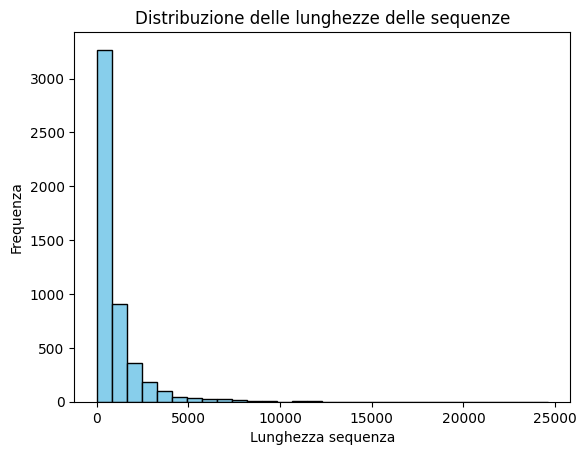

In [ ]:
#Determinazione max_sequence_length e successiva applicazione

#Calcolo delle lunghezze
sequence_lengths = [len(seq) for seq in texts]

#Creazione di un istogramma di frequenze assolute
plt.hist(sequence_lengths, bins=30, color='skyblue', edgecolor='black')
plt.title('Distribuzione delle lunghezze delle sequenze')
plt.xlabel('Lunghezza sequenza')
plt.ylabel('Frequenza')
plt.show()

La distribuzione delle lunghezze sembra abbastanza parlante. Per la determinazione del parametro ottimale di lunghezza (max_sequence_length) optiamo per il'80-esimo percentile della distribuzione.

In [ ]:
#max_sequence_length (80-esimo percentilie)
max_sequence_length = np.percentile(sequence_lengths, 80)
print(f"max_sequence_length: {int(max_sequence_length)}")

max_sequence_length: 1388


In [ ]:
#Padding: applicazione del padding col valore ottimale: in base all'osservazione precedente ("max_sequence_length: 1388") optiamo per una valore pari a 1400
max_sequence_length = 1400
data_padded = pad_sequences(sequences, maxlen = max_sequence_length)

## 3) Training, Test & Validation set
Di seguito costruiamo i vari sottoinsiemi del dataset necessari al training e alla validazione del modello. Nello specifico, possiamo riassumere il tutto nei seguenti step:

- 1) costruzione del training set per addestrare il modello;
- 2) costruzione del validation set: utilizzato per ottimizzare i parametri del modello e monitorare l'overfitting durante l'addestramento;
- 3) costruzione del test set: usato per valutare le performance finali del modello su dati mai visti.

In [ ]:
#Training e test set: 30% dei dati assegnato al test set. Inoltre, per le label, bisogna creare una vettorizzazione essendo un problema di classificazione multilabel
X = data_padded
y = df[['label_num']].values

#Check dimensioni
X.shape

(4993, 1400)

In [ ]:
#Training e test set: 30% dei dati assegnato al test set. Inoltre, per le label, bisogna creare una vettorizzazione essendo un problema di classificazione multilabel
X = data_padded
y = df[['label_num']].values

#Check dimensioni
X.shape

#NB: utilizziamo la stratify option in modo da bilanciare la distribuzione di spam e non spam in tutti nel set di training e non

#Step 1: divisione iniziale in due set: il primo servirà per venire poi risuddiviso in training e
#validation set (X_temp e y_temp) mentre la seconda parte servirà come test set (X_test, y_test).
#Il test set corrisponderà al 20% del dataset complessivo.
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

#Step 2: divisione in training e validation per il training del modello (divideremo dal X_temp e y_temp).
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.30, stratify=y_temp, random_state=42)

#Check dimensioni
print(f"Dimensione Training Set: {len(X_train)}")
print(f"Dimensione Validation Set: {len(X_val)}")
print(f"Dimensione Test Set: {len(X_test)}")

Dimensione Training Set: 2795
Dimensione Validation Set: 1199
Dimensione Test Set: 999


In [ ]:
#Check post applicazione della stratify
count_train = Counter(y_train.flatten())
print(f"Distribuzione di spam e non spam nel train set: {dict(count_train)}")

count_val = Counter(y_val.flatten())
print(f"Distribuzione di spam e non spam nel validation set: {dict(count_val)}")

Distribuzione di spam e non spam nel train set: {np.int64(0): 1977, np.int64(1): 818}
Distribuzione di spam e non spam nel validation set: {np.int64(1): 351, np.int64(0): 848}


Osserviamo che, utilizzando la option stratify, abbiamo mantenuto correttamente le distribuzioni:

<br>

SPAM
- numero di spam (1) nel train set --> 818/2795 = 0.29
- numero di spam (1) nel validation set --> 351/1199 = 0.29

<br>

NO SPAM
- numero di non spam (0) nel train set --> 1977/2795 = 0.70
- numero di non spam (0) nel validation set --> 848/1199 = 0.70

## 4) Approcci modellistici
In questa sezione sperimenteremo nella creazione di una rete neurale in grado di riconoscere una mail spam. Inizieremo a considerare una prima MLP (Multi-Layer Perceptron) per poi esplorare le potenzialità di una LSTM.

### 4.1) Modellizzazione di una prima MLP
In questa prima sezione, proviamo a costruire una MLP. A tal proposito, adotteremo le funzionalità delle librerie tensorflow e keras.

<br>

#### Architettura della MLP
Costruiremo una prima MLP con tre strati nascosti (hidden layers) introducendo delle componenti di dropout e BatchNormalization:

<br>

- Layer 1 di tipo embedding in grado di converte gli indici delle parole in vettori densi di 128 dimensioni;

- Layer 2 di tipo flatten: appiattisce la matrice 2D dell'embedding in un unico vettore 1D;

- Layer 3 di tipo denso; corrisponde al primo strato completamente connesso, apprende combinazioni non lineari delle feature;

- Layer 4 di BatchNormalization: normalizza le attivazioni per migliorare la stabilità dell'addestramento;

- Layer 5 di droput che disattiva casualmente il 30% dei neuroni per prevenire overfitting;

- Layer 6 che corrisponde al secondo strato denso, riduce la dimensionalità e raffina l'estrazione delle feature;

- Layer 7 di BatchNormalization;

- Layer 8 di Dropout;

- Layer 9 che corrisponde al terzo strato denso, compatta ulteriormente le informazioni apprese;

- Layer 10 di BatchNormalization;

- Layer 11 di Dropout;

- Layer 12 di tipo denso, produce un singolo valore tra 0 e 1, interpretato come probabilità che l'email sia spam.

<br>

NB: è buona prassi applicare una clear_session() prima del lancio di una nuova rete in fase di testing.

In [ ]:
K.clear_session()

model1 = Sequential([
    #Embedding per convertire gli indici delle parole in vettori
    Embedding(input_dim=max_words, output_dim=128, input_length=max_sequence_length),

    #Appiattiamo l'output dell'embedding per la MLP
    Flatten(),

    #Primo hidden layer
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    #Secondo hidden layer
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    #Terzo hidden layer
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    #Output layer
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


#### Model compile & training
Di seguito compiliamo il modello tramite il comando "compile". Come funzione di loss optiamo per la binary crossentropy, essendo di fronte a un problema binario (ovvero 2 classi):

In [ ]:
model1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', 'Precision', 'Recall', 'AUC']#Monitoraggio delle metriche
)

In [ ]:
#Training del modello su 4 epoche (si potrebbe chiaramente aumentare)
history1 = model1.fit(X_train, y_train, batch_size=64,
                     epochs=4,
                     validation_data=(X_val, y_val)
                     )

Epoch 1/4
44/44 ━━━━━━━━━━━━━━━━━━━━ 42s 711ms/step - AUC: 0.5989 - Precision: 0.3702 - Recall: 0.5491 - accuracy: 0.5830 - loss: 0.7820 - val_AUC: 0.5176 - val_Precision: 0.2935 - val_Recall: 1.0000 - val_accuracy: 0.2952 - val_loss: 4.2456
Epoch 2/4
44/44 ━━━━━━━━━━━━━━━━━━━━ 38s 872ms/step - AUC: 0.8500 - Precision: 0.6663 - Recall: 0.7137 - accuracy: 0.8173 - loss: 0.4771 - val_AUC: 0.9169 - val_Precision: 0.2918 - val_Recall: 0.9801 - val_accuracy: 0.2977 - val_loss: 2.7667
Epoch 3/4
44/44 ━━━━━━━━━━━━━━━━━━━━ 34s 700ms/step - AUC: 0.9569 - Precision: 0.8626 - Recall: 0.9117 - accuracy: 0.9285 - loss: 0.2531 - val_AUC: 0.9582 - val_Precision: 0.3407 - val_Recall: 0.9658 - val_accuracy: 0.4429 - val_loss: 0.7371
Epoch 4/4
44/44 ━━━━━━━━━━━━━━━━━━━━ 42s 729ms/step - AUC: 0.9879 - Precision: 0.9488 - Recall: 0.9564 - accuracy: 0.9725 - loss: 0.1232 - val_AUC: 0.9940 - val_Precision: 1.0000 - val_Recall: 0.0171 - val_accuracy: 0.7123 - val_loss: 0.6727


In [ ]:
#Costruzione della curve di learning: costruzione delle liste necessarie
train_loss = history1.history['loss']
val_loss = history1.history['val_loss']
train_accuracy = history1.history['accuracy']
val_accuracy = history1.history['val_accuracy']
train_precision = history1.history['Precision']
val_precision = history1.history['val_Precision']

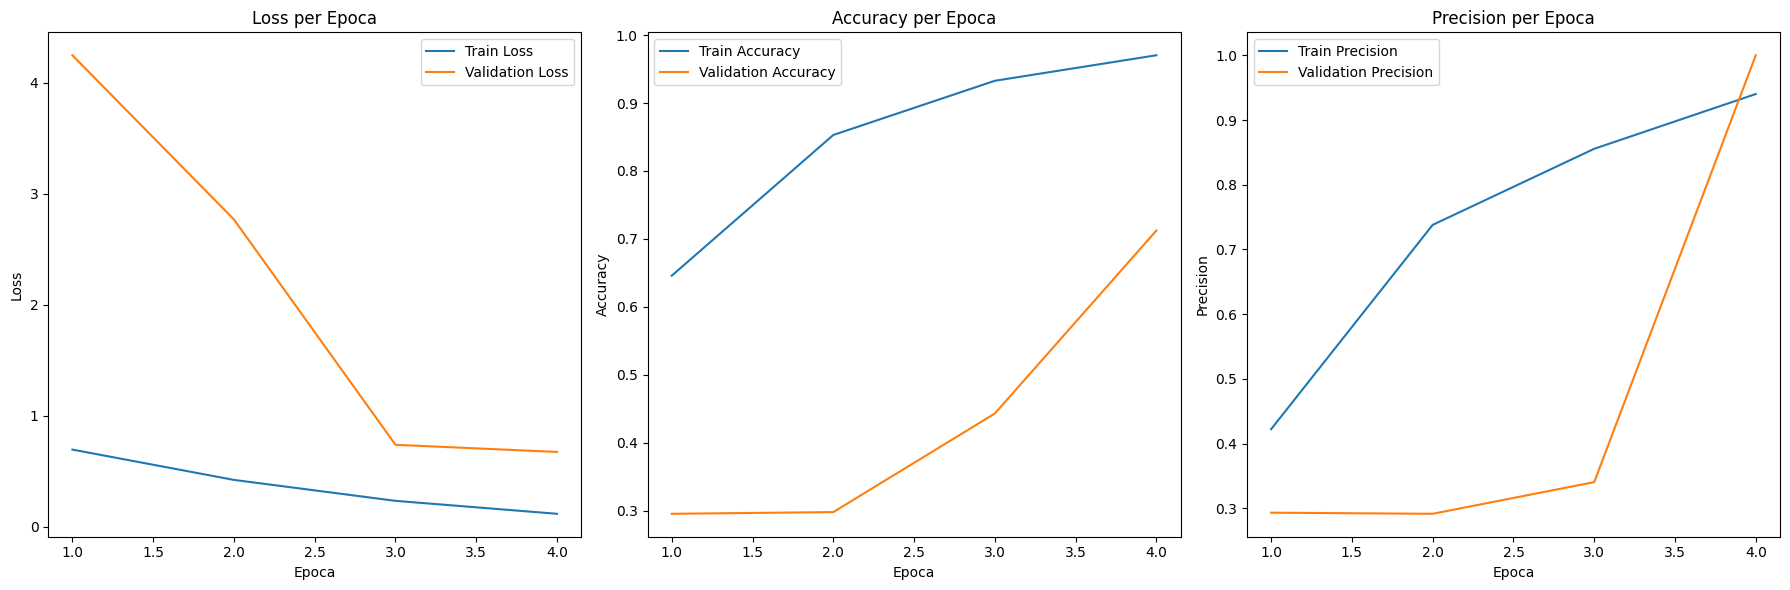

In [ ]:
#Plot delle learning curves
plt.figure(figsize=(18, 6))

#A) Curva della Loss
plt.subplot(1, 3, 1)  # Cambiato a 1x3 per fare spazio alla Precisione
plt.plot(range(1, 5), train_loss, label='Train Loss')
plt.plot(range(1, 5), val_loss, label='Validation Loss')
plt.title('Loss per Epoca')
plt.xlabel('Epoca')
plt.ylabel('Loss')
plt.legend()

#B) Curva dell'Accuracy
plt.subplot(1, 3, 2)
plt.plot(range(1, 5), train_accuracy, label='Train Accuracy')
plt.plot(range(1, 5), val_accuracy, label='Validation Accuracy')
plt.title('Accuracy per Epoca')
plt.xlabel('Epoca')
plt.ylabel('Accuracy')
plt.legend()

#C) Curva della Precision
plt.subplot(1, 3, 3)
plt.plot(range(1, 5), train_precision, label='Train Precision')
plt.plot(range(1, 5), val_precision, label='Validation Precision')
plt.title('Precision per Epoca')
plt.xlabel('Epoca')
plt.ylabel('Precision')
plt.legend()

#Grafico finale
plt.tight_layout()
plt.show()

In [ ]:
#Test del modello sui dati di validazione (che corrispondeva al 30% del dataset)
results = model1.evaluate(X_test, y_test)
print("Test Loss:", results[0])
print("Test Accuracy:", results[1])
print("Test Precision:", results[2])
print("Test Recall:", results[3])
print("Test AUC:", results[4])

32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - AUC: 0.9877 - Precision: 0.9394 - Recall: 0.0323 - accuracy: 0.7209 - loss: 0.6570
Test Loss: 0.6678793430328369
Test Accuracy: 0.717717707157135
Test Precision: 1.0
Test Recall: 0.037542663514614105
Test AUC: 0.9906578660011292


Possiamo notare che

<br>

- Loss:
la loss di training scende costantemente, come ci si aspetta.
La loss di validation invece subisce un brusco calo tra la terza e quarta epoca, che potrebbe indicare che ha il modello ha iniziato ad apprendere meglio il problema.

- Accuracy:
l'accuracy di training migliora progressivamente e arriva oltre il 90%.
L'accuracy della validation è all'inizio bassa, poi sembra aumentare segno che il modello stava sottofittando all'inizio e poi ha trovato un buon fit alla fine.

- Precision:
la Precision di training sale bene e arriva vicina al 90%. La Precision di validation è bassa nelle prime 2 epoche, poi aumenta quasi a 1 (molto alta).

<br>

Considerazioni finali sulle 4 epoche:
questo primo run non sembra mostrare segni di overfitting. Il comportamento delle metriche di validazione ("piatto e poi salto improvviso") potrebbe indicare che il modello, fino alla terza epoca, non stava ancora generalizzando bene. Questo fatto sembra venir suggerito anche dal fatto che sulle metriche del set di test notiamo però Precision altissima e Recall bassissima. Si potrebbe continuare l'addestramento aumentando di qualche epocha per vedere se le metriche di validazione continuano a migliorare o se comincia a manifestarsi un eventuale overfitting.


In [ ]:
#Training del modello su 6 epoche
history2 = model1.fit(X_train, y_train, batch_size=64,
                    epochs=6,
                    validation_data=(X_val, y_val)
                    )

Epoch 1/6
44/44 ━━━━━━━━━━━━━━━━━━━━ 31s 713ms/step - AUC: 0.9962 - Precision: 0.9735 - Recall: 0.9845 - accuracy: 0.9878 - loss: 0.0735 - val_AUC: 0.9972 - val_Precision: 1.0000 - val_Recall: 0.1453 - val_accuracy: 0.7498 - val_loss: 0.4143
Epoch 2/6
44/44 ━━━━━━━━━━━━━━━━━━━━ 39s 673ms/step - AUC: 0.9989 - Precision: 0.9858 - Recall: 0.9929 - accuracy: 0.9938 - loss: 0.0465 - val_AUC: 0.9966 - val_Precision: 1.0000 - val_Recall: 0.2621 - val_accuracy: 0.7840 - val_loss: 0.3526
Epoch 3/6
44/44 ━━━━━━━━━━━━━━━━━━━━ 42s 687ms/step - AUC: 0.9990 - Precision: 0.9781 - Recall: 0.9898 - accuracy: 0.9906 - loss: 0.0447 - val_AUC: 0.8623 - val_Precision: 1.0000 - val_Recall: 0.0342 - val_accuracy: 0.7173 - val_loss: 1.3034
Epoch 4/6
44/44 ━━━━━━━━━━━━━━━━━━━━ 43s 726ms/step - AUC: 0.9991 - Precision: 0.9915 - Recall: 0.9886 - accuracy: 0.9941 - loss: 0.0332 - val_AUC: 0.9951 - val_Precision: 0.9924 - val_Recall: 0.3704 - val_accuracy: 0.8148 - val_loss: 0.3888
Epoch 5/6
44/44 ━━━━━━━━━━━━━━━━

In [ ]:
#Costruzione della curve di learning: costruzione delle liste necessarie
train_loss = history2.history['loss']
val_loss = history2.history['val_loss']
train_accuracy = history2.history['accuracy']
val_accuracy = history2.history['val_accuracy']
train_precision = history2.history['Precision']
val_precision = history2.history['val_Precision']

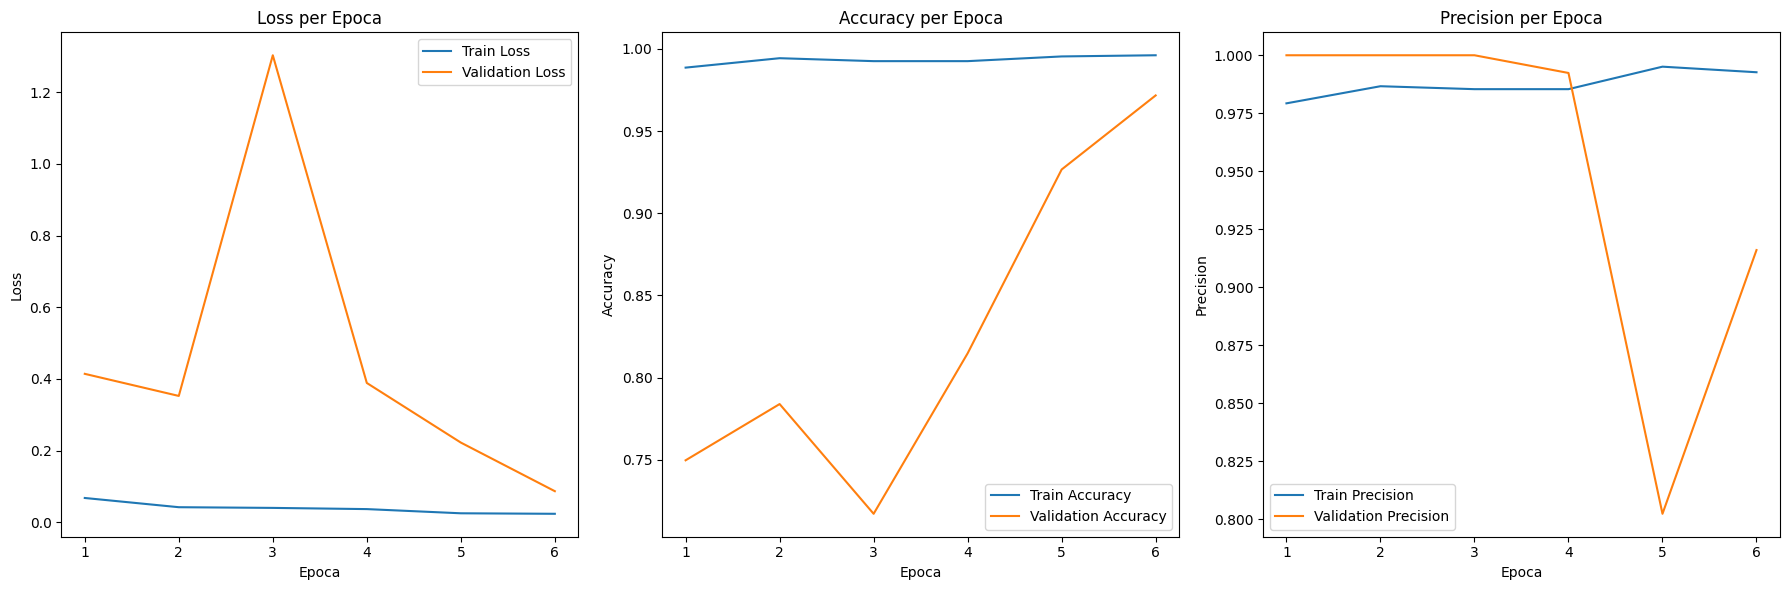

In [ ]:
#Plot delle learning curves
plt.figure(figsize=(18, 6))

#A) Curva della Loss
plt.subplot(1, 3, 1)  # Cambiato a 1x3 per fare spazio alla Precisione
plt.plot(range(1, 7), train_loss, label='Train Loss')
plt.plot(range(1, 7), val_loss, label='Validation Loss')
plt.title('Loss per Epoca')
plt.xlabel('Epoca')
plt.ylabel('Loss')
plt.legend()

#B) Curva dell'Accuracy
plt.subplot(1, 3, 2)
plt.plot(range(1, 7), train_accuracy, label='Train Accuracy')
plt.plot(range(1, 7), val_accuracy, label='Validation Accuracy')
plt.title('Accuracy per Epoca')
plt.xlabel('Epoca')
plt.ylabel('Accuracy')
plt.legend()

#C) Curva della Precision
plt.subplot(1, 3, 3)
plt.plot(range(1, 7), train_precision, label='Train Precision')
plt.plot(range(1, 7), val_precision, label='Validation Precision')
plt.title('Precision per Epoca')
plt.xlabel('Epoca')
plt.ylabel('Precision')
plt.legend()

#Grafico finale
plt.tight_layout()
plt.show()

In [ ]:
#Test del modello sui dati di validazione (che corrispondeva al 30% del dataset)
results = model1.evaluate(X_test, y_test)
print("Test Loss:", results[0])
print("Test Accuracy:", results[1])
print("Test Precision:", results[2])
print("Test Recall:", results[3])
print("Test AUC:", results[4])

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - AUC: 0.9924 - Precision: 0.8826 - Recall: 0.9931 - accuracy: 0.9599 - loss: 0.1462
Test Loss: 0.11938050389289856
Test Accuracy: 0.9649649858474731
Test Precision: 0.9006211161613464
Test Recall: 0.9897611141204834
Test AUC: 0.9957821369171143


Possiamo notare che l'aggiunta di qualche epoca in più, ha nettamente migliorato le performance come si vede anche dai grafici. Per la validation loss possiamo notare che alla terza epoca è come se avvennisse un'instabilità temporanea, magari dovuta ad esempi "ambigui" da classificare. Non sembra anche qui esserci segno di overfitting, dato che poi la loss continua ad assumere un trend negativo. Un discorso simile può essere fatto anche per il grafico dell'Accuracy: alla terza epoca notiamo un leggero calo (da 0.78 si passa a 0.71 fino a 0.81 per poi notare un trend sempre positivo). Per la Recall notiamo un comportamento interessante; osserviamo che:

<br>

- EPOCA 1: (Recall, Precision) = (0.14, 1)
- EPOCA 2: (Recall, Precision) = (0.26, 1)
- EPOCA 3: (Recall, Precision) = (0.03, 1)
- EPOCA 4: (Recall, Precision) = (0.37, 0.99)
- EPOCA 5: (Recall, Precision) = (0.99, 0.80)
- EPOCA 6: (Recall, Precision) = (0.99, 0.91)

<br>

Dalla prima alla terza epoca sembra che il modello prevedesse quasi sempre la classe negativa ma quando prevedeva positivo tale previsione era corretta (potremmo dire una sorta di comportamento "difensivo"). Alla quarta epoca il modello è come se iniziasse a "osare" di più per poi sempre più arrivare a un compromesso tra Recall e Precision (il modello cerca poi di tenere sempre meno falsi positivi). In conclusione, sembra che il modello abbia appreso la classe positiva trovando un giusto equilibrio. Questo fatto sembra ora venir suggerito notando che la Presion e la Recall del set di test sembrano ora più coerenti rispetto alla MLP a 4 epoche.

#### Salvataggio del modello MLP

In [ ]:
#Salvataggio del modello (NB. h5 è un formato di salvataggio tipico per salvare modelli di deep learning)
model1.save("/content/drive/MyDrive/ProfessionAI-Progetto8-MatteoMarcoCosta/model1_spam_classifier.keras")

In [ ]:
#Riutilizzo del modello: in caso di riutilizzo, si può richiamare il modello salvato senza dovero
#riaddestrare tutto da capo. Il formato h5 tiene conto dell'architettura della rete e di tutti i
#dettagli intrischi dall'applicazione della compile function.
from tensorflow.keras.models import load_model
model1_loaded = load_model("/content/drive/MyDrive/ProfessionAI-Progetto8-MatteoMarcoCosta/model1_spam_classifier.keras")

### Approfondimento: qualche esperimento tramite Random Search
In questa ultima sezione sulle MLP, proviamo ad sperimentare con una tecnica di Random Search per provare a individuare una MLP migliore tra diversi parametri di input prossimi a quelli adottati nelle due MLP precedenti. Considereremo la stessa architettura considerata delle due MLP prima create: tre hidden layers e uno finale di output.

In [ ]:
#Iniziamo a costruire una function che crei il modello e che questo venga implementato su vari iperparametri (variabile di input hp).
#La variabile hp verrà poi gestita dal tuner (vedi script successivo) avendo specificato nella build_mlp la function hp.Choice. hp.Int, etc. ...
def build_mlp(hp):
    K.clear_session()
    model = Sequential()
    model.add(Embedding(
        input_dim=max_words,
        output_dim=128,
        input_length=max_sequence_length
    ))
    model.add(Flatten())

    #Primo hidden layer
    model.add(Dense(
        units=hp.Int('units1', min_value=64, max_value=256, step=64),
        activation='relu'
    ))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Choice('dropout1', [0.2, 0.3, 0.5])))

    #Secondo hidden layer
    model.add(Dense(
        units=hp.Int('units2', min_value=32, max_value=128, step=32),
        activation='relu'
    ))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Choice('dropout2', [0.2, 0.3, 0.5])))

    #Terzo hidden layer
    model.add(Dense(
        units=hp.Int('units3', min_value=16, max_value=64, step=16),
        activation='relu'
    ))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Choice('dropout3', [0.2, 0.3, 0.5])))

    #Output layer
    model.add(Dense(1, activation='sigmoid'))

    #Ottimizzatore Adam su 3 tipi di learning rate
    lr = hp.Choice('lr', [1e-2, 1e-3, 3e-4])#Learning rate
    opt = Adam(learning_rate=lr)

    #Model compile
    model.compile(
        optimizer=opt,
        loss='binary_crossentropy',#Loss function
        metrics=['accuracy', 'Precision', 'Recall', 'AUC']#Metriche
    )

    return model

In [ ]:
#Random Search
tuner = kt.RandomSearch(
    build_mlp,#Il parametro hp viene scelto in base alle max_trials definite (nel nostro caso sono 5)
    objective='val_accuracy',
    max_trials=5,  #Quante combinazioni provare
    executions_per_trial=1,
    directory='mlp_tuning',
    project_name='mlp_search'
)

tuner.search(
    X_train, y_train,#Dati di training
    epochs=5,#Optiamo per 5 epoche
    validation_data=(X_val, y_val)#Dati di validazione
)

#Miglior modello trovato dalla Random Search
best_model = tuner.get_best_models(1)[0]

Trial 5 Complete [00h 11m 26s]
val_accuracy: 0.9199332594871521

Best val_accuracy So Far: 0.9783152341842651
Total elapsed time: 00h 44m 56s


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 32 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
#Check sui vari modelli (elenco iperparametri)
tuner.results_summary()

Results summary
Results in mlp_tuning/mlp_search
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 3 summary
Hyperparameters:
units1: 192
dropout1: 0.3
units2: 96
dropout2: 0.3
units3: 48
dropout3: 0.3
lr: 0.001
Score: 0.9783152341842651

Trial 0 summary
Hyperparameters:
units1: 256
dropout1: 0.3
units2: 64
dropout2: 0.3
units3: 16
dropout3: 0.5
lr: 0.01
Score: 0.9624687433242798

Trial 1 summary
Hyperparameters:
units1: 192
dropout1: 0.5
units2: 128
dropout2: 0.5
units3: 64
dropout3: 0.3
lr: 0.0003
Score: 0.9282735586166382

Trial 4 summary
Hyperparameters:
units1: 256
dropout1: 0.3
units2: 96
dropout2: 0.3
units3: 16
dropout3: 0.5
lr: 0.0003
Score: 0.9199332594871521

Trial 2 summary
Hyperparameters:
units1: 128
dropout1: 0.2
units2: 96
dropout2: 0.2
units3: 16
dropout3: 0.2
lr: 0.001
Score: 0.8832360506057739


In [ ]:
#Miglior modello (già addestrato con i migliori iperparametri)
best_model = tuner.get_best_models(num_models=1)[0]

#Migliori iperparametri trovati
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("Migliori iperparametri trovati:")
for param, value in best_hps.values.items():
    print(f"{param}: {value}")

Migliori iperparametri trovati:
units1: 192
dropout1: 0.3
units2: 96
dropout2: 0.3
units3: 48
dropout3: 0.3
lr: 0.001


Notiamo che gli iperparametri trovati su queste cinque prove, non si discostano di molto dai parametri usati nelle precedenti MLP. Pertanto un terzo modello di MLP si potrebbe costruire andando a considerare tali iperparametri. Continuiamo ora con la sezione che segue in cui proviamo ad esplorare la costruzione di una LSTM. L'aspetto interessante di queste rete neurali è la loro "memoria interna".

### 4.2) Modellizzazione di una rete neurale ricorrente
Passiamo alla costruzione della LSTM. Anche in questo caso, utilizzeremo le funzionalità delle librerie tensorflow e keras.

<br>

#### Architettura della LSTM
L'architettura della LSTM che andremo a costruire prevederà la presenza di 6 layers:

<br>

- Layer 1 (Embedding): questo primo layer trasforma gli indici interi delle parole (ottenuti nella fase di tokenizzazione) in vettori densi di dimensione fissa;
- Layer 2 (LSTM): elaborazione delle sequenze mantenendo informazioni di lungo termine grazie alla sua struttura ricorrente, uso di 64 neuroni nel layer, valorizzazione a True per connettersi al LSTM layer successivo;
- Layer 3 (BatchNormalization): può essere utile tra i layer LSTM e dopo il layer Dense per stabilizzare il training;
- Layer 4 (Dropout): livello intermedio per riduzione di eventuali overfitting;
- Layer 5 (LSTM): secondo LSTM layer;
- Layer 6 (BatchNormalization)
- Layer 7 (Dropout): un secondo livello intermedio per riduzione di eventuali overfitting;
- Layer 8 (Dense): essendo un problema di classificazione binario, per il layer finale optiamo a un layer che preveda come funzione di attivazione una sigmoide.

<br>

Per ora ci baseremo su questa struttura; chiaramente, può sempre essere ottimizzata aggiungendo più layers nello strato nascosto.

NB: è buona prassi applicare una clear_session() prima del lancio di una nuova rete in fase di testing.

In [ ]:
#LSTM architettura neurale: il parametro max_words corrisponde al numero massimo di parole del vocabolario
K.clear_session()

model_lstm = Sequential([
             Embedding(input_dim=max_words, output_dim=128, input_length=max_sequence_length),
             LSTM(64, return_sequences=True),
             BatchNormalization(),
             Dropout(0.2),
             LSTM(64),
             BatchNormalization(),
             Dropout(0.2),
             Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


#### Model compile & funzione di loss
Di seguito compiliamo il modello tramite il comando "compile". Nello specifico, adotteremo la tecnica
di ottimizzazione ADAM (Adaptive Moment Estimation). Come funzione di loss optiamo per la binary crossentropy, essendo di fronte a un problema binario (ovvero 2 classi).

In [ ]:
#Compilazione della LSTM: uso della binary_crossentropy, più adatta per un problema multilabel
model_lstm.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.002),
              loss='binary_crossentropy',
              metrics=['accuracy', 'Precision', 'Recall', 'AUC'])#Monitoraggio delle metriche

In [ ]:
#Costruzione di una tecnica di early stopping
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(monitor='val_loss',#Quale metrica monitorare per l'overfitting
                               patience=3,#Permette al modello di continuare per 3 epoche senza migliorare prima di fermarsi
                               restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(monitor='val_loss',
                              factor=0.5,
                              patience=2,
                              min_lr=1e-6)#Impedisce che il learning rate diventi troppo piccolo

In [ ]:
#Training del modello
history_lstm1 = model_lstm.fit(X_train, y_train, batch_size=64,
                    epochs=5,
                    validation_data=(X_val, y_val),
                    callbacks=[early_stopping, reduce_lr])

Epoch 1/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 197s 4s/step - AUC: 0.8469 - Precision: 0.5694 - Recall: 0.7574 - accuracy: 0.7605 - loss: 0.4968 - val_AUC: 0.9949 - val_Precision: 0.9876 - val_Recall: 0.6781 - val_accuracy: 0.9033 - val_loss: 0.4092 - learning_rate: 0.0020
Epoch 2/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 200s 4s/step - AUC: 0.9969 - Precision: 0.9730 - Recall: 0.9687 - accuracy: 0.9836 - loss: 0.0651 - val_AUC: 0.9969 - val_Precision: 0.9725 - val_Recall: 0.9060 - val_accuracy: 0.9650 - val_loss: 0.2548 - learning_rate: 0.0020
Epoch 3/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 188s 4s/step - AUC: 0.9992 - Precision: 0.9787 - Recall: 0.9884 - accuracy: 0.9905 - loss: 0.0350 - val_AUC: 0.9934 - val_Precision: 0.9731 - val_Recall: 0.8234 - val_accuracy: 0.9416 - val_loss: 0.2041 - learning_rate: 0.0020
Epoch 4/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 194s 4s/step - AUC: 0.9989 - Precision: 0.9907 - Recall: 0.9795 - accuracy: 0.9912 - loss: 0.0346 - val_AUC: 0.9973 - val_Precision: 0.9659 - val_Recall: 0.9687 - val_accu

In [ ]:
#Costruzione della curve di learning: costruzione delle liste necessarie
train_loss = history_lstm1.history['loss']
val_loss = history_lstm1.history['val_loss']
train_accuracy = history_lstm1.history['accuracy']
val_accuracy = history_lstm1.history['val_accuracy']
train_precision = history_lstm1.history['Precision']
val_precision = history_lstm1.history['val_Precision']

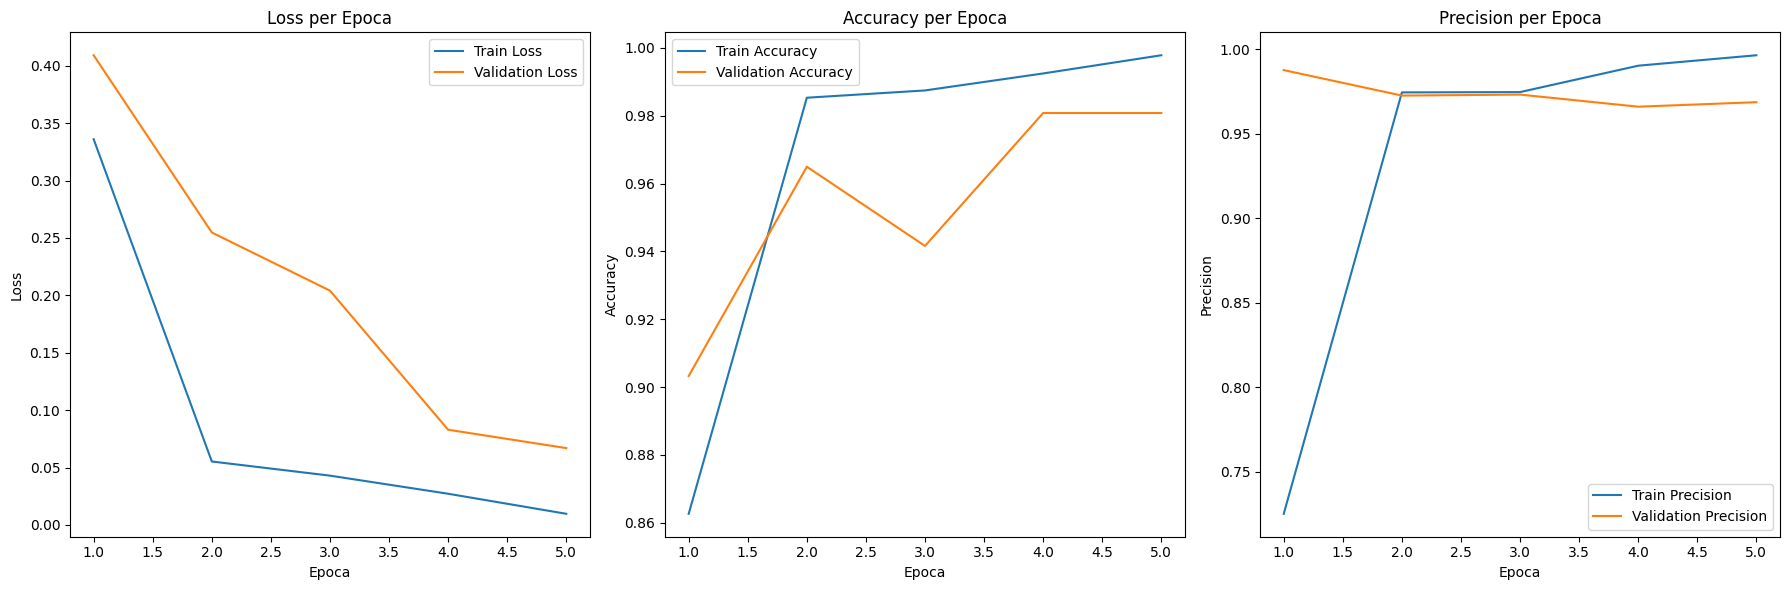

In [ ]:
#Plot delle learning curves
plt.figure(figsize=(18, 6))

#A) Curva della Loss
plt.subplot(1, 3, 1)  # Cambiato a 1x3 per fare spazio alla Precisione
plt.plot(range(1, 6), train_loss, label='Train Loss')
plt.plot(range(1, 6), val_loss, label='Validation Loss')
plt.title('Loss per Epoca')
plt.xlabel('Epoca')
plt.ylabel('Loss')
plt.legend()

#B) Curva dell'Accuracy
plt.subplot(1, 3, 2)
plt.plot(range(1, 6), train_accuracy, label='Train Accuracy')
plt.plot(range(1, 6), val_accuracy, label='Validation Accuracy')
plt.title('Accuracy per Epoca')
plt.xlabel('Epoca')
plt.ylabel('Accuracy')
plt.legend()

#C) Curva della Precision
plt.subplot(1, 3, 3)
plt.plot(range(1, 6), train_precision, label='Train Precision')
plt.plot(range(1, 6), val_precision, label='Validation Precision')
plt.title('Precision per Epoca')
plt.xlabel('Epoca')
plt.ylabel('Precision')
plt.legend()

#Grafico finale
plt.tight_layout()
plt.show()

In [ ]:
#Test del modello sui dati di validazione (che corrispondeva al 30% del dataset)
results = model_lstm.evaluate(X_test, y_test)
print("Test Loss:", results[0])
print("Test Accuracy:", results[1])
print("Test Precision:", results[2])
print("Test Recall:", results[3])
print("Test AUC:", results[4])

32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 439ms/step - AUC: 0.9944 - Precision: 0.9073 - Recall: 0.9718 - accuracy: 0.9631 - loss: 0.0998
Test Loss: 0.10016237944364548
Test Accuracy: 0.9639639854431152
Test Precision: 0.9213114976882935
Test Recall: 0.9590443968772888
Test AUC: 0.9939982891082764


Dai grafici e dal validation set, possiamo notare che il modello sembra generalizzare abbastanza bene. Si può notare che la loss bassa e l'Accuracy e la Precision alte suggeriscono che il modello apprende bene. In particolare:

<br>

- Loss: la training loss diminuisce costantemente e rapidamente, arrivando vicino a zero all'ultima epoca. La validation loss invece parte leggermente più alta, ma poi diminuisce raggiungendo sempre più la training loss.

- Accuracy: la training Accuracy migliora molto velocemente e supera la soglia del 90% già dalla seconda epoca. La validation Accuracy sembra avere un calo alla terza epoca per poi risalire mantenendo soglie sopra il 95%. Non sembra essere un segno di overfitting ma piuttosto del fatto che il modello abbia iniziato a generalizzare meglio.

- Precision: la training Precision migliora molto e si avvicina a 1. La validation precision è alta dall'inizio, ma tende a stabilizzarsi leggermente più bassa rispetto al training stando sempre sopra la soglia del 96%.

In [ ]:
#Salvataggio del modello (NB. h5 è un formato di salvataggio tipico per salvare modelli di deep learning)
model_lstm.save("/content/drive/MyDrive/ProfessionAI-Progetto8-MatteoMarcoCosta/lstm_model_2_spam_classifier.keras")

In [ ]:
#Riutilizzo del modello: in caso di riutilizzo, si può richiamare il modello salvato senza dovero
#riaddestrare tutto da capo. Il formato h5 tiene conto dell'architettura della rete e di tutti i
#dettagli intrischi dall'applicazione della compile function.
from tensorflow.keras.models import load_model
model_lstm_loaded = load_model("/content/drive/MyDrive/ProfessionAI-Progetto8-MatteoMarcoCosta/lstm_model_2_spam_classifier.keras")

### Considerazioni sulle due reti neurali prima addestrate
La LSTM sta catturando molto bene la struttura sequenziale del testo; nel nostro contesto per la costruzione di uno spam filter è un vantaggio perché l'ordine delle parole e i pattern linguistici fanno la differenza.
La MLP iniziale che abbiamo testato è stato comunque un buon esperimento; sarebbe necessario l'uso di più epoche e probabilmente considerare un vocabolario più ricco per avvicinarsi alle metriche della LSTM.
Possiamo concludere che la MLP è una buona come baseline veloce e semplice, utile se vuoi addestrare in pochi secondi o su hardware debole. La LSTM è chiaramente migliore in accuratezza e precisione, più robusta su testi complessi, ma un po' più lenta da addestrare.

## 5) LDA: Individuare i Topic principali tra le email classificate come SPAM e calcolo della distanza semantica tra i topics ottenuti per valutare l'eterogeneità dei contenuti delle email SPAM
In questa sezione cerchiamo di costruire una metodologia in grado di estrarre i topic principali dalle mail del dataset considerate come spam. La tecnica che adotteremo sarà quella della LDA (Latent Dirichlet Allocation). Seguendo l'idea di Blei (vedi https://www.jmlr.org/papers/volume3/blei03a/blei03a.pdf), l'idea di fondo della LDA è di andare a determinare K topic nascosti sotto l'ipotesi che ogni topic sia una distribuzione di parole e che ogni documento sia un combinazione di uno o più topic. Nello specifico, la distribuzione di parole associata a ogni topic è campionata da una Dirichlet:

<br>

$$
p(w, z, \theta, \phi \mid \alpha, \beta) = \prod_{k=1}^{K} p(\phi_k \mid \beta) \cdot \prod_{d=1}^{D} p(\theta_d \mid \alpha) \cdot \prod_{n=1}^{N_d} p(z_{dn} \mid \theta_d) \cdot p(w_{dn} \mid \phi_{z_{dn}})
$$

<br>

dove:
<br>
- $D$ = numero di documenti
- $K$ = numero di topic
- $N_d$  = numero di parole nel documento $d$
- $\theta_d \sim Dir(\alpha)$ = distribuzione dei topic per documento
- $\phi_k \sim Dir(\beta)$ = distribuzione delle parole per topic
- $z_{dn}$ = topic della parola $n$ del documento $d$
- $w_{dn}$ = parola osservata

<br>

In particolare, si suppone che:
<br>
- $\phi_k \sim \text{Dir}(\beta)$ per ogni topic $k = 1,...,K$;
- $\theta_d \sim \text{Dir}(\alpha)$ per ogni documento $d = 1,...,D$;
- $z_{dn} \sim \text{Mult}(\theta_d)$ (scelta del topic);
- $w_{dn} \sim \text{Mult}(\phi_{z_{dn}})$ (scelta della parola)

<br>

Una volta stimate le distribuzioni dei topic $\phi_k$ e dei topic nei documenti $\theta_d$ tramite LDA, con i parametri della Dirichlet $\alpha$ per $\theta_d$ e $\beta$ per $\phi_k$, si può applicare la regola di Bayes per calcolare la probabilità inversa:

<br>

$$p(z, \theta, \phi \mid w, \alpha, \beta) = \frac{p(w, z, \theta, \phi \ | \ \alpha,\beta)}{p(w \ | \ \alpha, \beta)}.$$

<br>

Per la costruzione della LDA, proviamo a sperimentare anche con la gensim library. Per ulteriori approfondimenti:
https://radimrehurek.com/gensim/auto_examples/index.html

In [ ]:
#Import e uso della gensim library (eventuale istallazione con #!pip install gensim)
import nltk
import gensim
from gensim import corpora, models
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
#Consideriamo solo le mail spam del dataset
spam_emails = df[df['label_num'] == 1]['text'].tolist()

In [ ]:
#Funzione di preprocessing
def preprocess(text):
    tokens = word_tokenize(text.lower())
    tokens = [t for t in tokens if t not in stopwords.words('english') and t not in string.punctuation]
    return tokens

processed_emails = [preprocess(email) for email in spam_emails]

#Dizionario e corpus (uso della corpora di gensim)
dictionary = corpora.Dictionary(processed_emails)
corpus = [dictionary.doc2bow(email) for email in processed_emails]

#Sintassi per costruire la LDA (fissiamo un random_state altrimenti si potrebbero ottenere topic diversi)
n = 5
lda_model = models.LdaModel(corpus, num_topics=n, id2word=dictionary, passes=10, random_state=42)

#Individuazione dei topic global tramite la LDA
topics = lda_model.print_topics(num_words=5)
for idx, topic in topics:
    print(f"Topic {idx + 1}: {topic}")

Topic 1: 0.010*"company" + 0.007*"statements" + 0.005*"price" + 0.005*"information" + 0.004*"may"
Topic 2: 0.014*"td" + 0.012*"nbsp" + 0.011*"height" + 0.010*"font" + 0.009*"http"
Topic 3: 0.006*"subject" + 0.004*"e" + 0.004*"``" + 0.004*"http" + 0.004*"new"
Topic 4: 0.016*"3" + 0.010*"com" + 0.009*"subject" + 0.007*"www" + 0.007*"2"
Topic 5: 0.012*"subject" + 0.004*"us" + 0.004*"email" + 0.004*"get" + 0.004*"please"


Possiamo notare l'individuazione dei $K=5$ argomenti (topics) impostati per la LDA. Ogni topic viene infatti visto come una somma pesata di parole ritenuti interessanti. Ogni topic è un vettore di probabilità $\phi_k$, definito come

<br>

$$\boldsymbol{\phi}_k = \bigl( p(w_1 \mid z = k), \, p(w_2 \mid z = k), \, \ldots, \, p(w_V \mid z = k) \bigr)$$

<br>

dove $V$ è il numero di parole nel dizionario (vocabolario). La somma di tutte le probabilità nel topic è pari a 1:

<br>

$$\sum_{i=1}^{V} p(w_i \mid z = k) = 1,$$

<br>

Le parole con probabilità più alte sono quelle che maggiormente rappresentano il topic $k$. Nel nostro caso possiamo osservare che il TOPIC 1 potrebbe essere messaggi di offerte da parte di qualche compagnia (magari nel mese di maggio per via della parola "may") e così via.
Proviamo ora a determinare i topic principali rilevati nelle mail spam e le parole principalmente presenti in essi. Proviamo a sperimentare con la pyLDAvis library. Il cuore della metodologia risiede anche nell'uso di particolari metriche: la SALIENCY e la RELEVANCE.

<br>

### 5.1) Saliency
$
\text{saliency}(w) = \text{frequency}(w) \cdot \left[ \sum_t p(t \mid w) \cdot \log \left( \frac{p(t \mid w)}{p(t)} \right) \right]
$

<br>

Serve per ordinare i termini più “interessanti” nell'intero corpus indipendentemente dal topic dove:

<br>

- $w$ indica una generica parola;
- $t$ è un topic;
- $p(t | w)$ è la probabilità che la parola $w$ appartenga al topic $t$;
- $p(t)$ è la probabilità complessiva del topic $t$;
- $frequency(w)$ indica quante volte appare la parola nel corpus.

<br>

Possiamo osservare che la saliency è alta per le parole che appaiono spesso o sono discriminative (cioè associate più a certi topic che ad altri).

<br>

### 5.2) Relevance
$
\text{relevance}(w \mid t) = \lambda \cdot p(w \mid t) + (1 - \lambda) \cdot \frac{p(w \mid t)}{p(w)}
$

<br>

Tale metrica serve per ordinare le parole nel pannello a destra quando selezioni un topic. Nello specifico:

<br>

- $p(w | t)$ è quanto è probabile la parola w dato il topic $t$;
- $p(w)$ è la frequenza della parola nel corpus;
- $λ$ è lo slider tra 0 e 1 per controllare la rilevanza vs esclusività.

<br>

Chiaramente se $λ = 1$ allora vengono mostrate le parole più frequenti nel topic, senza considerare se esistono anche in altri. Se invece $λ = 0$ allora vengono mostrate le parole più esclusive, cioè molto probabili nel topic $t$ ma rare globalmente. Valori intermedi (ad esempio 0.5) bilanciano tra le due. Questo bilanciamento è fondamentale per interpretare meglio i topic:

<br>

- le parole con alta $p(w|t)$ ma anche alta $p(w)$ (tipo “email”, “user”) non sono così informative;
- le parole con alto $p(w|t)/p(w)$ (cioè rare ma distintive) sono più caratterizzanti per quel topic.

In [ ]:
#Per avere una visualizzazione grafica delle parole, uso della pyLDAvis library (eventuale istallazione tramite il comando !pip install pyLDAvis)
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

#Preparazione dei dati per la visualizzazione (consideriamo l'lda_model prima costruito sui 5 argomenti)
vis_data = gensimvis.prepare(lda_model, corpus, dictionary)

#Notebook dinamico
pyLDAvis.enable_notebook()
pyLDAvis.display(vis_data)

Selezionando uno specifico argomento dal grafico della Distance Map (costruito sul sottoinsieme delle mail spam), è possibile poi osservare il numero delle 30 parole più rilevanti per esso. Se i cerchi sono molto sovrapposti, i topic sono simili comunque poco eterogenei, se invece sono sparsi e distanti, si hanno topic ben distinti, quindi contenuti spam variegati. Chiaramente il grafico si basa di fondo su una riduzione della dimensionalità: una possibile perdita di informazione potrebbe essere inevitabile


### 6) Estrarre dalle email NON SPAM le informazioni sulle Organizzazioni menzionate
Si tratta di un problema di name recognition (NER). L'idea è di andare a  identificare e classificare entità nominate all'interno di un testo, come persone, organizzazioni, luoghi e altre categorie semantiche. Proveremo a sperimentare l'uso della spacy library.

<br>

#### 6.1) Libreria spacy
Si tratta di una libreria open source di NLP progettata per comprendere il linguaggio umano (nello specifico testi scritti). Di seguito un esempio sulle principali funzionalità invocabili nella libreria.

In [ ]:
import spacy
from collections import defaultdict

#Loading di un modello (es. lingua italiana)
nlp = spacy.load("en_core_web_sm")

#Specifichiamo il testo da analizzare
doc = nlp("Cristoforo Colombo was a famous italian explorer. Agip is an important oil industry.")

#Stampa token, lemma e POS tagging
for token in doc:
    print(token.text, token.lemma_, token.pos_)

/usr/local/lib/python3.11/dist-packages/spacy/cli/_util.py:23: DeprecationWarning: Importing 'parser.split_arg_string' is deprecated, it will only be available in 'shell_completion' in Click 9.0.
  from click.parser import split_arg_string
/usr/local/lib/python3.11/dist-packages/weasel/util/config.py:8: DeprecationWarning: Importing 'parser.split_arg_string' is deprecated, it will only be available in 'shell_completion' in Click 9.0.
  from click.parser import split_arg_string


Cristoforo Cristoforo PROPN
Colombo Colombo PROPN
was be AUX
a a DET
famous famous ADJ
italian italian ADJ
explorer explorer NOUN
. . PUNCT
Agip Agip PROPN
is be AUX
an an DET
important important ADJ
oil oil NOUN
industry industry NOUN
. . PUNCT


In [ ]:
#Stampa le entità riconosciute (ad esempio Agip viene riconosciuta come una organizzazione ---> ORG si riferisce a istituzioni, enti, aziende, ...)
for ent in doc.ents:
  print(ent.text, ent.label_)

Cristoforo Colombo ORG
italian NORP
Agip ORG


Proviamo ora ad applicare queste funzionalità alle mail non spam per ottenere informazioni sulle organizzazioni.

In [ ]:
#Carica il modello di lingua inglese (il dataset df, costruito sul csv, è in lingua inglese)
nlp = spacy.load("en_core_web_sm")

#Dizionario per salvare le organizzazioni per ogni email
orgs_by_email = defaultdict(list)

#Tutte le mail non spam
non_spam_emails = df[df['label_num'] == 0]['text'].tolist()

#Ciclo su tutte le email NON SPAM
for idx, email in enumerate(non_spam_emails):
    #Applicazione del NLP sul contenuto testuale della mail (esegue sulla singola mail un'analisi linguistica completa come tokenizzazione, NER, ...)
    doc = nlp(email)

    #Estrae tutte le entità riconosciute da spaCy (doc.ents) e filtra solo quelle con label "ORG", cioè Organizzazioni, tramite il comando "ent"
    orgs = [ent.text for ent in doc.ents if ent.label_ == "ORG"]

    #Filtro per escludere entità troppo brevi
    #orgs = [ent.text for ent in doc.ents if ent.label_ == "ORG" and len(ent.text) > 2]

    #Salvataggio della lista di organizzazioni nel dizionario orgs_by_email, usando come chiave l’indice idx (cioè l’indice dell’email)
    orgs_by_email[idx] = orgs

In [ ]:
#Possibile output (ripulito tramite regex)
orgs_by_email = defaultdict(list)

for idx, email in enumerate(non_spam_emails):
    doc = nlp(email)#NB: doc in space esegue l'analisi linguistica sulla email
    #Prendiamo tutte le entità riconosciute e filtriamo solo quelle con etichetta "ORG" tramite regex
    orgs = [
        ent.text.strip()
        for ent in doc.ents
        if ent.label_ == "ORG"
        and len(ent.text.strip()) > 2#Per evitare "rumore", ovvero stringhe di 1 o 2 caratteri
        and re.search(r"[A-Za-z]", ent.text)
    ]
    orgs_by_email[idx] = orgs#Colleghiamo l'email al suo elenco di organizzazioni

#Output finale di mail che contengono informazioni sulle organizzazioni: in pratica a ogni mail corrisponde un indice a cui associamo le possibili organizzazioni trovate
emails_with_orgs = {k: v for k, v in orgs_by_email.items() if v}#Creazione di un dizionario
print(emails_with_orgs)

{1: ['xls'], 5: ['bearer', 'foot locker canada'], 7: ['xls'], 10: ['nathan l hlavaty / hou', 'mary m smith / hou /', 'zivley / hou', 'darron c\ngiron / hou', 'riley / hou /', 'austin / hou /', 'christy sweeney / hou'], 11: ['riley / hou /', 'mike morris / corp / enron @'], 12: ['boas / hou'], 16: ['xls'], 22: ['neuweiler / hou'], 23: ['the houston expl', 'megan parker / corp / enron', 'the houston expl'], 25: ['the enron corp .', 'cst'], 26: ['the texas gas group', 'lozano / hou', 'lozano / hou', 'north america corp .', 'lozano / hou'], 30: ['ami chokshi / corp / enron', 'ami chokshi / corp / enron @ enron'], 32: ['doc'], 34: ['zivley / hou', 'cico oil & gas'], 35: ['samson lone star limited 9845'], 36: ['canedy', 'jen black', 'brenda', 'sutton', 'trisha', 'devers @ columbia', 'syscom - inc .', 'michelle', 'daniel', 'nyu', 'nyu', 'janelle mccan', 'abercrombie'], 40: ['pg &', 'pg & e texas', 'sherlyn', 'pg & e texas', 'pg & e texas bulletin board', 'pg & e texas', 'pg & e texas', 'pg & 

Dall'ultimo output, ad esempio, sembra che diverse email (identificate dall'indice numerico) contengono possibili nomi di organizzazioni.

## Conclusioni
Abbiamo esplorato due tipologie di reti neurali per la costruzione di un filtro antispam partendo da un csv contenente mail spam e non spam. La prima rete neurale considerata, consisteva in una MLP con tre strati nascosti, la seconda una LSTM. Abbiamo anche provato a portare da 4 a 6 epoche il run della MLP, osservando un certo migliormento nelle metriche di classificazione. La LSTM si è comunque rivelata più robusta rispetto alle MLP precedentemente implementate, essendo questa più performate sui contenuti testuali grazie alla sua "memoria interna", in grado di cattuare in modo più specifico pattern linguistici. Non abbiamo optato a procedure massive di oversampling o undersampling (se non quella di eliminare eventuali mail duplicate), essendo il dataset abbastanza bilanciato tra mail spam e non (30% vs 70% rispettivamente, all'interno del dataset). Abbiamo poi esplorato, tramite tecniche di LDA, problematiche relative alla topic extraction.

<br>

#### Link utili
- Articolo originale di Blei sulla LDA: https://www.jmlr.org/papers/volume3/blei03a/blei03a.pdf